In [ ]:
import requests
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from datetime import datetime

In [2]:
load_dotenv()
WAQI_TOKEN = os.getenv("WAQI_TOKEN")

In [3]:
LAT, LON = 30.1978 , 71.4719

## AQICN

In [4]:
# url = f"https://api.waqi.info/feed/multan/?token={WAQI_TOKEN}"
# response = requests.get(url)
# data = response.json()

# print(data)

In [5]:
# station_ids = {
#     "Women University": "A544288",
#     "District Officer Industries": "A544444",
#     "BZU Multan": "A576622",
#     "Walled Cities Authority": "A544066"
# }

# for name, station_id in station_ids.items():
#     url = f"https://api.waqi.info/feed/{station_id}/?token={WAQI_TOKEN}"
#     resp = requests.get(url).json()
#     if resp["status"] == "ok":
#         aqi = resp["data"].get("aqi", "N/A")
#         time = resp["data"]["time"]["s"]
#         print(f"{name}: AQI={aqi}, last reported={time}")
#     else:
#         print(f"{name}: ERROR - {resp}")

In [6]:
# url = f"https://api.waqi.info/feed/A544288/?token={WAQI_TOKEN}"
# response = requests.get(url)
# data = response.json()
# print(data)

In [7]:
# url = f"https://api.waqi.info/feed/A544288/?token={WAQI_TOKEN}"
# resp = requests.get(url).json()

# data = resp["data"]
# iaqi = data["iaqi"]  # nested dict of individual pollutants

# flat = {"aqi": data["aqi"], "timestamp": data["time"]["s"]}
# for pollutant, val in iaqi.items():
#     flat[pollutant] = val["v"]

# print(flat)

## Open Meteo

In [8]:
url = "https://api.open-meteo.com/v1/forecast"
params = {
    "latitude": LAT,
    "longitude": LON,
    "current": "temperature_2m,relative_humidity_2m,wind_speed_10m,surface_pressure,cloud_cover,precipitation",
    "timezone": "Asia/Karachi"
}

resp = requests.get(url, params=params).json()
print(resp)

{'latitude': 30.193321, 'longitude': 71.47369, 'generationtime_ms': 0.1385211944580078, 'utc_offset_seconds': 18000, 'timezone': 'Asia/Karachi', 'timezone_abbreviation': 'GMT+5', 'elevation': 143.0, 'current_units': {'time': 'iso8601', 'interval': 'seconds', 'temperature_2m': '°C', 'relative_humidity_2m': '%', 'wind_speed_10m': 'km/h', 'surface_pressure': 'hPa', 'cloud_cover': '%', 'precipitation': 'mm'}, 'current': {'time': '2026-08-08T06:15', 'interval': 900, 'temperature_2m': 25.6, 'relative_humidity_2m': 96, 'wind_speed_10m': 6.1, 'surface_pressure': 984.8, 'cloud_cover': 46, 'precipitation': 0.2}}


In [9]:
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": LAT,
    "longitude": LON,
    "start_date": "2025-08-01",
    "end_date": "2026-07-31",
    "hourly": "temperature_2m,relative_humidity_2m,wind_speed_10m,surface_pressure,cloud_cover,precipitation",
    "timezone": "Asia/Karachi"
}

resp = requests.get(url, params=params).json()
df_weather = pd.DataFrame(resp["hourly"])

df_weather.head()

,time,temperature_2m,relative_humidity_2m,wind_speed_10m,surface_pressure,cloud_cover,precipitation
0,2025-08-01T00:00,31.4,74,5.8,982.1,13,0.0
1,2025-08-01T01:00,30.9,77,6.7,981.8,84,0.0
2,2025-08-01T02:00,30.6,77,6.1,981.4,100,0.0
3,2025-08-01T03:00,30.4,76,5.5,981.1,100,0.0
4,2025-08-01T04:00,30.1,74,6.1,981.3,100,0.0


In [10]:
url = "https://air-quality-api.open-meteo.com/v1/air-quality"
params = {
    "latitude": LAT,
    "longitude": LON,
    "current": "us_aqi,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,dust,ammonia",
    "timezone": "Asia/Karachi"
}

resp = requests.get(url, params=params).json()
print(resp["current"])

{'time': '2026-08-08T06:00', 'interval': 3600, 'us_aqi': 169, 'pm2_5': 81.5, 'pm10': 133.2, 'carbon_monoxide': 936.0, 'nitrogen_dioxide': 17.0, 'sulphur_dioxide': 6.5, 'ozone': 54.0, 'dust': 105.0, 'ammonia': None}


In [11]:
url = "https://air-quality-api.open-meteo.com/v1/air-quality"
params = {
    "latitude": LAT,
    "longitude": LON,
    "start_date": "2025-08-01",
    "end_date": "2026-07-31",
    "hourly": "us_aqi,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,dust",
    "timezone": "Asia/Karachi"
}

resp = requests.get(url, params=params).json()
df_aqi = pd.DataFrame(resp["hourly"])

df_aqi.head()

,time,us_aqi,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,dust
0,2025-08-01T00:00,152,77.3,122.9,378.0,24.8,5.4,49.0,86.0
1,2025-08-01T01:00,153,75.0,120.1,342.0,22.9,5.1,46.0,90.0
2,2025-08-01T02:00,153,73.8,122.0,315.0,21.9,4.9,42.0,93.0
3,2025-08-01T03:00,154,74.0,129.5,293.0,22.8,4.8,37.0,92.0
4,2025-08-01T04:00,154,70.1,123.4,278.0,24.5,4.8,32.0,90.0


In [12]:
print(df_weather.shape)
print(df_weather.isnull().sum())

print(df_aqi.shape)
print(df_aqi.isnull().sum())

(8760, 7)
time                    0
temperature_2m          0
relative_humidity_2m    0
wind_speed_10m          0
surface_pressure        0
cloud_cover             0
precipitation           0
dtype: int64
(8760, 9)
time                0
us_aqi              0
pm2_5               0
pm10                0
carbon_monoxide     0
nitrogen_dioxide    0
sulphur_dioxide     0
ozone               0
dust                0
dtype: int64


## Merging

In [13]:
df_merged = pd.merge(df_weather, df_aqi, on="time", how="inner")
print(df_merged.shape)
df_merged.head()

(8760, 15)


,time,temperature_2m,relative_humidity_2m,wind_speed_10m,surface_pressure,cloud_cover,precipitation,us_aqi,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,dust
0,2025-08-01T00:00,31.4,74,5.8,982.1,13,0.0,152,77.3,122.9,378.0,24.8,5.4,49.0,86.0
1,2025-08-01T01:00,30.9,77,6.7,981.8,84,0.0,153,75.0,120.1,342.0,22.9,5.1,46.0,90.0
2,2025-08-01T02:00,30.6,77,6.1,981.4,100,0.0,153,73.8,122.0,315.0,21.9,4.9,42.0,93.0
3,2025-08-01T03:00,30.4,76,5.5,981.1,100,0.0,154,74.0,129.5,293.0,22.8,4.8,37.0,92.0
4,2025-08-01T04:00,30.1,74,6.1,981.3,100,0.0,154,70.1,123.4,278.0,24.5,4.8,32.0,90.0


In [14]:
df_merged["time"] = pd.to_datetime(df_merged["time"])
df_merged = df_merged.sort_values("time")

## Validation

In [15]:
print(df_merged.describe())

                      time  temperature_2m  relative_humidity_2m  \
count                 8760     8760.000000           8760.000000   
mean   2026-01-30 11:30:00       26.661416             52.853653   
min    2025-08-01 00:00:00        3.100000              8.000000   
25%    2025-10-31 05:45:00       20.100000             38.000000   
50%    2026-01-30 11:30:00       28.100000             51.000000   
75%    2026-05-01 17:15:00       33.500000             67.000000   
max    2026-07-31 23:00:00       45.200000            100.000000   
std                    NaN        8.657016             19.869929   

       wind_speed_10m  surface_pressure  cloud_cover  precipitation  \
count     8760.000000       8760.000000  8760.000000    8760.000000   
mean         7.865936        991.824132    24.858676       0.026769   
min          0.000000        975.800000     0.000000       0.000000   
25%          5.000000        985.400000     0.000000       0.000000   
50%          7.700000        991

In [16]:
print(df_merged.columns.tolist())

['time', 'temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 'surface_pressure', 'cloud_cover', 'precipitation', 'us_aqi', 'pm2_5', 'pm10', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'dust']


In [17]:
checks = {
    "temperature_2m": (-10, 55),        # Multan can hit ~50°C in summer, rarely below freezing
    "relative_humidity_2m": (0, 100),   # hard physical bound
    "wind_speed_10m": (0, 150),         # km/h, generous upper bound for storms
    "surface_pressure": (900, 1050),    # hPa, realistic range at Multan's elevation
    "cloud_cover": (0, 100),            # percentage, hard bound
    "precipitation": (0, None),         # can't be negative
    "us_aqi": (0, 500),                 # hard bound, official AQI scale cap
    "pm2_5": (0, None),
    "pm10": (0, None),
    "dust": (0, None),
}

for col, (low, high) in checks.items():
    if col not in df_merged.columns:
        continue
    below = df_merged[df_merged[col] < low] if low is not None else pd.DataFrame()
    above = df_merged[df_merged[col] > high] if high is not None else pd.DataFrame()
    print(f"{col}: {len(below)} below {low}, {len(above)} above {high}")

temperature_2m: 0 below -10, 0 above 55
relative_humidity_2m: 0 below 0, 0 above 100
wind_speed_10m: 0 below 0, 0 above 150
surface_pressure: 0 below 900, 0 above 1050
cloud_cover: 0 below 0, 0 above 100
precipitation: 0 below 0, 0 above None
us_aqi: 0 below 0, 0 above 500
pm2_5: 0 below 0, 0 above None
pm10: 0 below 0, 0 above None
dust: 0 below 0, 0 above None


In [18]:
print("Duplicate timestamps:", df_merged["time"].duplicated().sum())
print("Total rows:", len(df_merged))
print("Expected rows (full year, hourly):", 365*24, "or", 366*24, "for a leap year")

# Check for actual gaps in the hourly sequence
full_range = pd.date_range(start=df_merged["time"].min(), end=df_merged["time"].max(), freq="h")
missing_hours = full_range.difference(df_merged["time"])
print("Missing hours in sequence:", len(missing_hours))

Duplicate timestamps: 0
Total rows: 8760
Expected rows (full year, hourly): 8760 or 8784 for a leap year
Missing hours in sequence: 0


## Visualization

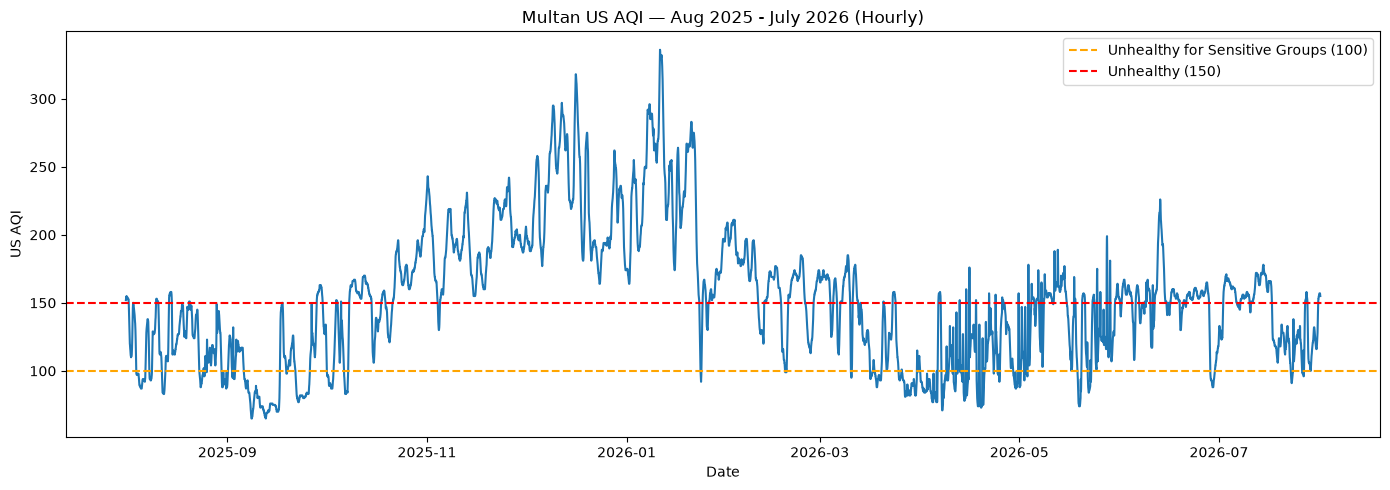

In [19]:
plt.figure(figsize=(14, 5))
plt.plot(df_merged["time"], df_merged["us_aqi"])
plt.title("Multan US AQI — Aug 2025 - July 2026 (Hourly)")
plt.xlabel("Date")
plt.ylabel("US AQI")
plt.axhline(y=100, color='orange', linestyle='--', label='Unhealthy for Sensitive Groups (100)')
plt.axhline(y=150, color='red', linestyle='--', label='Unhealthy (150)')
plt.legend()
plt.tight_layout()
plt.show()

<Figure size 1200x500 with 0 Axes>

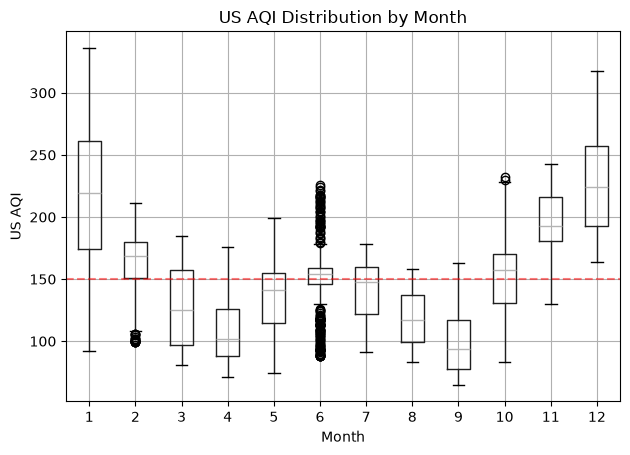

In [20]:
df_merged["month"] = df_merged["time"].dt.month

plt.figure(figsize=(12, 5))
df_merged.boxplot(column="us_aqi", by="month")
plt.title("US AQI Distribution by Month")
plt.suptitle("")
plt.xlabel("Month")
plt.ylabel("US AQI")
plt.axhline(y=150, color='red', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

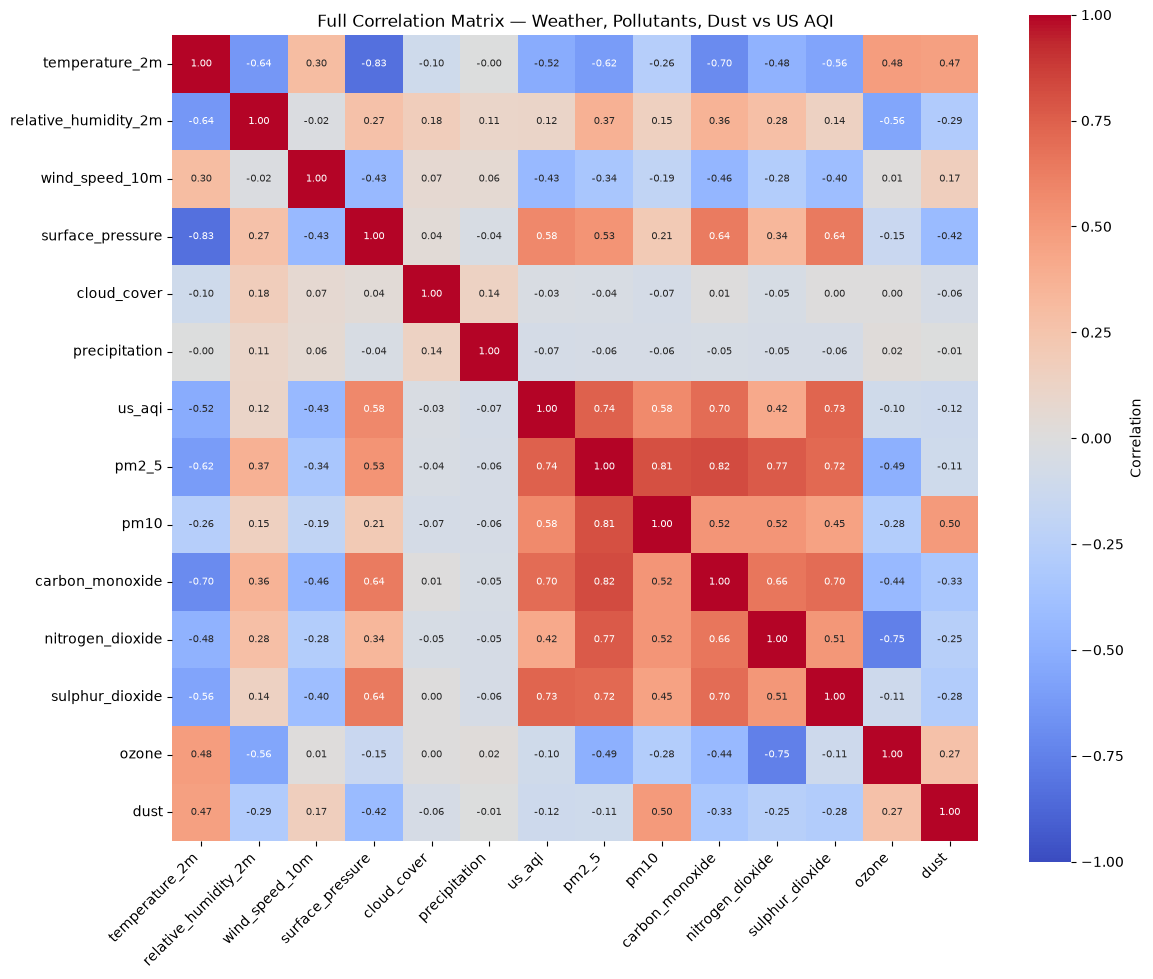

In [21]:
corr_cols = ['temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 
             'surface_pressure', 'cloud_cover', 'precipitation', 'us_aqi', 
             'pm2_5', 'pm10', 'carbon_monoxide', 'nitrogen_dioxide', 
             'sulphur_dioxide', 'ozone', 'dust']

corr_matrix = df_merged[corr_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
            square=True, cbar_kws={"label": "Correlation"}, annot_kws={"size": 7})
plt.title("Full Correlation Matrix — Weather, Pollutants, Dust vs US AQI")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

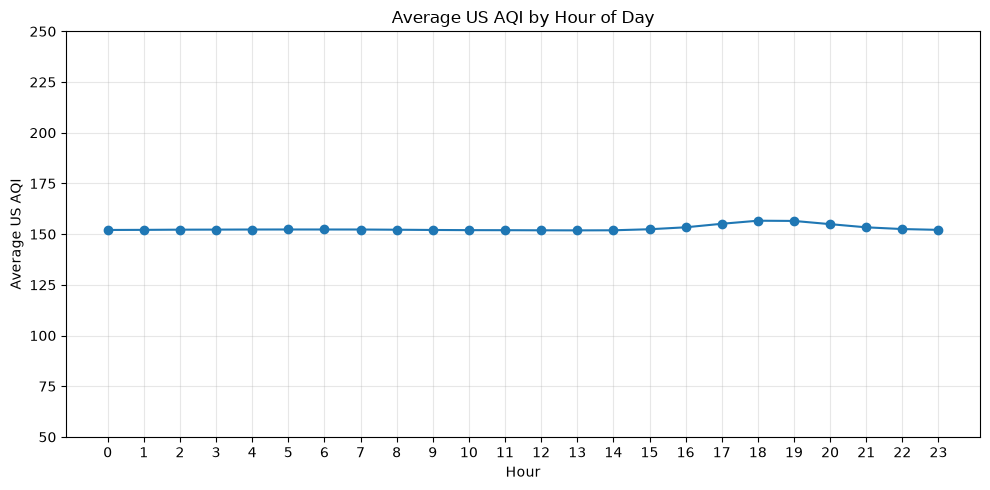

In [22]:
df_merged["hour"] = df_merged["time"].dt.hour

hourly_avg = df_merged.groupby("hour")["us_aqi"].mean()

plt.figure(figsize=(10, 5))
hourly_avg.plot(kind="line", marker="o")
plt.title("Average US AQI by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Average US AQI")
plt.ylim(50, 250)
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Investigation the outliers in June

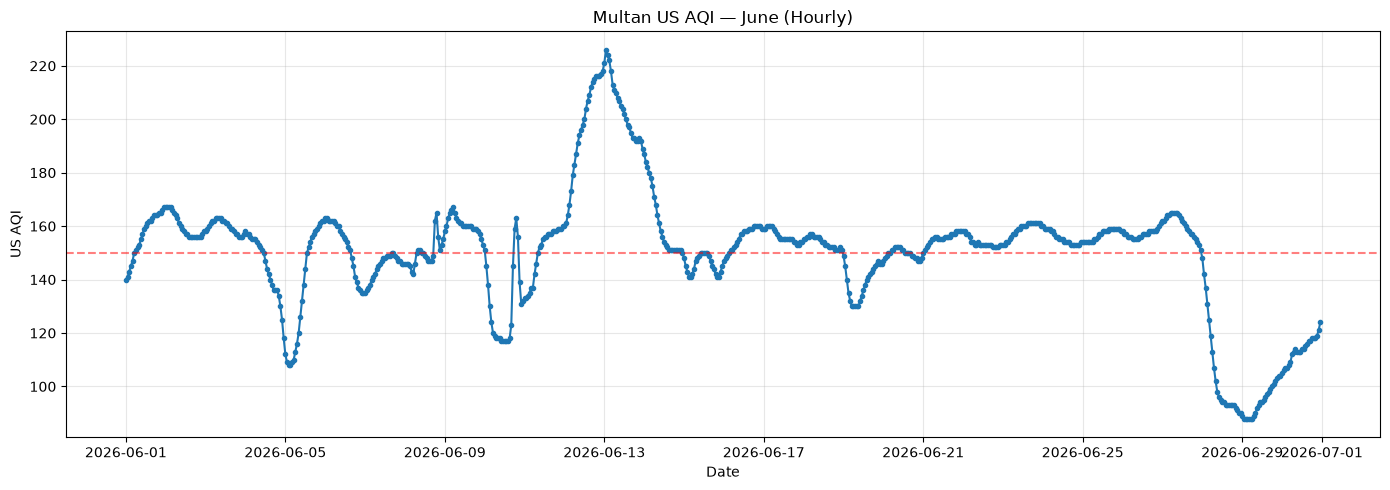

In [23]:
df_june = df_merged[df_merged["time"].dt.month == 6].copy()
df_june = df_june.sort_values("time")

plt.figure(figsize=(14, 5))
plt.plot(df_june["time"], df_june["us_aqi"], marker=".")
plt.title("Multan US AQI — June (Hourly)")
plt.xlabel("Date")
plt.ylabel("US AQI")
plt.axhline(y=150, color='red', linestyle='--', alpha=0.5)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
q1 = df_june["us_aqi"].quantile(0.25)
q3 = df_june["us_aqi"].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = df_june[(df_june["us_aqi"] < lower_bound) | (df_june["us_aqi"] > upper_bound)]
print(f"IQR bounds: {lower_bound:.1f} to {upper_bound:.1f}")
print(f"Number of outlier hours: {len(outliers)}")
outliers[["time", "us_aqi", "temperature_2m", "wind_speed_10m", "precipitation", "dust"]].sort_values("us_aqi")

IQR bounds: 126.5 to 178.5
Number of outlier hours: 140


,time,us_aqi,temperature_2m,wind_speed_10m,precipitation,dust
7972,2026-06-29 04:00:00,88,34.3,17.1,0.0,45.0
7971,2026-06-29 03:00:00,88,34.6,15.9,0.0,51.0
7974,2026-06-29 06:00:00,88,33.3,16.4,0.0,51.0
7973,2026-06-29 05:00:00,88,34.0,16.4,0.0,41.0
7970,2026-06-29 02:00:00,88,35.5,16.2,0.0,52.0
...,...,...,...,...,...,...
7588,2026-06-13 04:00:00,218,28.0,11.4,0.0,425.0
7584,2026-06-13 00:00:00,221,29.5,9.9,0.0,480.0
7587,2026-06-13 03:00:00,222,28.5,9.9,0.0,454.0
7586,2026-06-13 02:00:00,224,29.2,9.1,0.0,475.0


In [25]:
df_merged.to_csv(r"..\Data\sample_data.csv",index=False)